# Exercise 2: Sinusoids and the DFT

## Summary

This exercise develops an understanding of sinusoidal signals and the Discrete Fourier Transform (DFT). It covers generating real and complex sinusoids, implementing the DFT and inverse DFT from their mathematical definitions, and computing the magnitude spectrum of a discrete-time signal.

The implementations use NumPy and are validated against expected numerical results and NumPy's built-in FFT functions.

## Topics Covered

- Discrete-time real sinusoids
- Complex sinusoids
- Amplitude, frequency, phase, and sampling rate
- Sampling theorem and Nyquist frequency
- Aliasing
- Angular frequency and phase increments
- Euler's complex exponential
- Discrete Fourier Transform
- Inverse Discrete Fourier Transform
- Frequency bins
- DC component
- Magnitude spectrum
- Positive and negative frequency components
- Spectral symmetry
- Spectral leakage
- Floating-point numerical precision
- Signal reconstruction

## Skills Learned

- Generate sampled real sinusoids with NumPy.
- Generate complex exponentials for specific DFT frequency bins.
- Implement the DFT using the definition:

  $$
  X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}
  $$

- Implement the IDFT using the definition:

  $$
  x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]e^{j2\pi kn/N}
  $$

- Compute the magnitude spectrum using the absolute value of a complex spectrum.
- Plot the real and imaginary parts of signals and spectra.
- Identify the DC component in a DFT output.
- Convert DFT bin indices into physical frequencies.
- Compare a custom DFT implementation with `np.fft.fft()`.
- Validate signal reconstruction using `idft(dft(x))`.
- Measure reconstruction accuracy using maximum absolute error.
- Interpret small floating-point residuals in numerical computations.
- Explain why real signals produce symmetric positive- and negative-frequency peaks.
- Recognize spectral leakage when a sinusoid does not align with a DFT bin.
- Understand how changing signal amplitude affects spectral magnitude.

## Implemented Functions

- `gen_sine(A, f, phi, fs, t)`  
  Generates a real-valued sinusoid.

- `gen_complex_sine(k, N)`  
  Generates a complex sinusoid for a selected DFT frequency bin.

- `dft(x)`  
  Computes the discrete Fourier transform of a sequence.

- `idft(X)`  
  Computes the inverse discrete Fourier transform.

- `gen_mag_spec(x)`  
  Computes the magnitude spectrum of a sequence.

## Key Takeaways

- The sampling rate must be greater than twice the signal frequency to avoid aliasing.
- The phase parameter shifts a sinusoid in time.
- A complex sinusoid rotates around the unit circle with a phase increment of $(2\pi k/N)$.
- The DFT measures how strongly each discrete frequency component is present in a signal.
- The zero-frequency bin represents the DC component.
- The IDFT reconstructs the original signal using a $(1/N)$ scaling factor.
- Real-valued signals have conjugate-symmetric DFT spectra.
- A sinusoid aligned with a DFT bin produces concentrated spectral peaks.
- A sinusoid between DFT bins produces spectral leakage across neighboring bins.
- Very small imaginary or real-valued residuals are usually caused by floating-point precision.

## Technologies Used

- Python
- NumPy
- Matplotlib
- IPython Audio

<!-- EXERCISE-2-SUMMARY:END -->

## Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

## Part 1 - Generate a real sinusoid

### 1.1 Implement `gen_sine()`

In [2]:
def gen_sine(A, f, phi, fs, t):

    N = int(t * fs)
    time = np.arange(N) / fs
    x = A * np.cos(2 * np.pi * f * time + phi)

    return x

x = gen_sine(
    A=1.0,
    f=10.0,
    phi=1.0,
    fs=50,
    t=0.1
)

print(x)

[ 0.54030231 -0.63332387 -0.93171798  0.05749049  0.96724906]


### 1.2 Plot and play the sinusoid

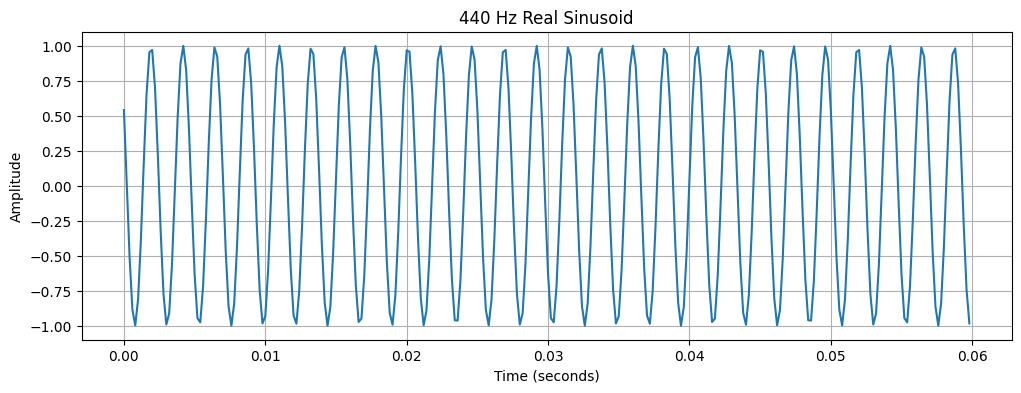

In [3]:
A = 1.0
f = 440.0
phi = 1.0
fs = 5000
t = 0.5

x = gen_sine(A, f, phi, fs, t)

time = np.arange(len(x)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time[:300], x[:300])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("440 Hz Real Sinusoid")
plt.grid(True)
plt.show()

ipd.display(ipd.Audio(data=x, rate=fs))

## Part 2- Generate a complex sinusoid 

### 2.1 Make the `gen_complex_sine` Function

In [5]:
def gen_complex_sine(k, N):
    n = np.arange(N)
    phase = 2 * np.pi * k * n / N

    return np.exp(1j * phase)

c_sine = gen_complex_sine(1,5)

print(c_sine)

[ 1.        +0.j          0.30901699+0.95105652j -0.80901699+0.58778525j
 -0.80901699-0.58778525j  0.30901699-0.95105652j]


### 2.2 Plot Real and Imaginary Parts

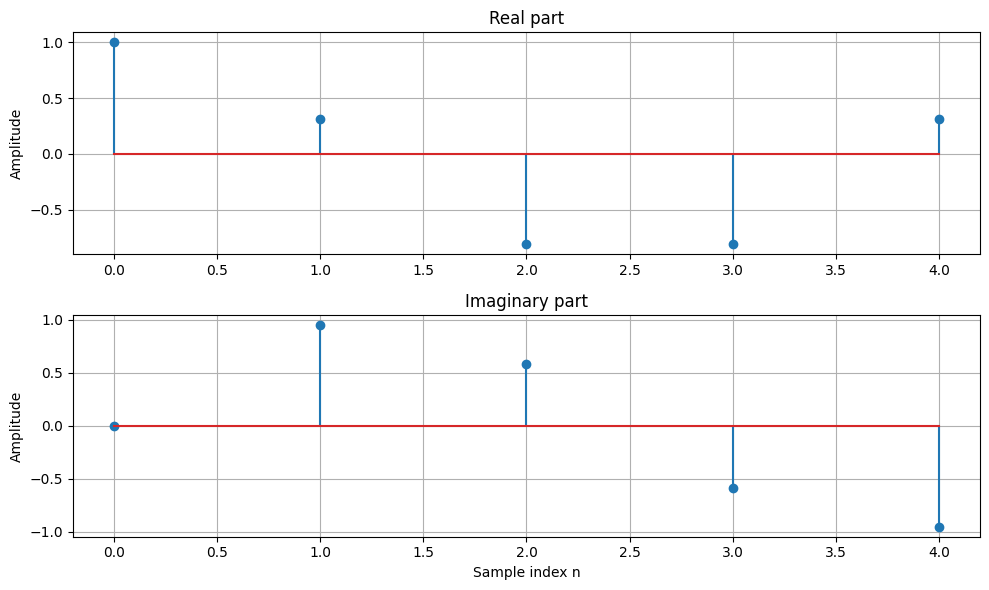

In [7]:
k = 1
N = 5

c_sine = gen_complex_sine(k, N)
n = np.arange(N)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.stem(n, np.real(c_sine))
plt.title("Real part")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(n, np.imag(c_sine))
plt.title("Imaginary part")
plt.xlabel("Sample index n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## Part 3 - Implement the discrete Fourier transform (DFT)

### 3.1 Implement `dft()` Function

In [ ]:
def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)

    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)

    return X

### 3.2 Observe the DFT of a simple signal

In [20]:
x = np.array([1, 2, 3, 4])
X = dft(x)
print(X)

[10.+0.00000000e+00j -2.+2.00000000e+00j -2.-9.79717439e-16j
 -2.-2.00000000e+00j]


# Implement the inverse discrete Fourier transform (IDFT)

### 4.1 Implement `idft()` Function

In [22]:
def idft(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)

    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)
        x[n] /= N

    return x

### 4.2 Plot Real/Imaginary parts of a signal

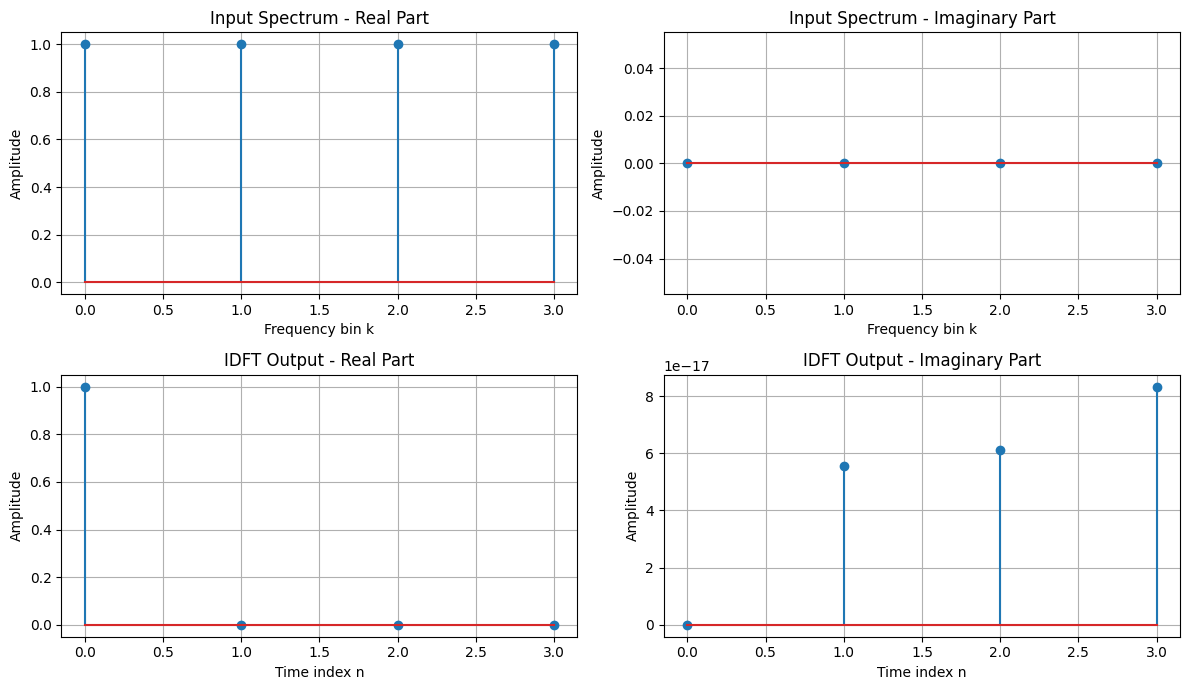

In [23]:
# Input spectrum
X = np.array([1, 1, 1, 1], dtype=complex)

# Compute the IDFT
x = idft(X)

# Frequency-bin/time-sample indices
indices = np.arange(len(X))

# Create four subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Input spectrum: real part
axes[0, 0].stem(indices, X.real)
axes[0, 0].set_title("Input Spectrum - Real Part")
axes[0, 0].set_xlabel("Frequency bin k")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True)

# Input spectrum: imaginary part
axes[0, 1].stem(indices, X.imag)
axes[0, 1].set_title("Input Spectrum - Imaginary Part")
axes[0, 1].set_xlabel("Frequency bin k")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True)

# IDFT output: real part
axes[1, 0].stem(indices, x.real)
axes[1, 0].set_title("IDFT Output - Real Part")
axes[1, 0].set_xlabel("Time index n")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True)

# IDFT output: imaginary part
axes[1, 1].stem(indices, x.imag)
axes[1, 1].set_title("IDFT Output - Imaginary Part")
axes[1, 1].set_xlabel("Time index n")
axes[1, 1].set_ylabel("Amplitude")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## Part - 5 Compute the magnitude spectrum

### 5.1 Implement `gen_mag_spec()`

In [26]:
def gen_mag_spec(x):
    X = dft(x)
    magnitude_spectrum = np.abs(X)

    return magnitude_spectrum

x = np.array([1, 2, 3, 4])
X_mag = gen_mag_spec(x)
print(X_mag)

[10.          2.82842712  2.          2.82842712]


### 5.2 Plot the cosine and magnitude spectrum

Peak bin: 410
Peak frequency: 800.78125 Hz
Peak magnitude: 193.90305335910884


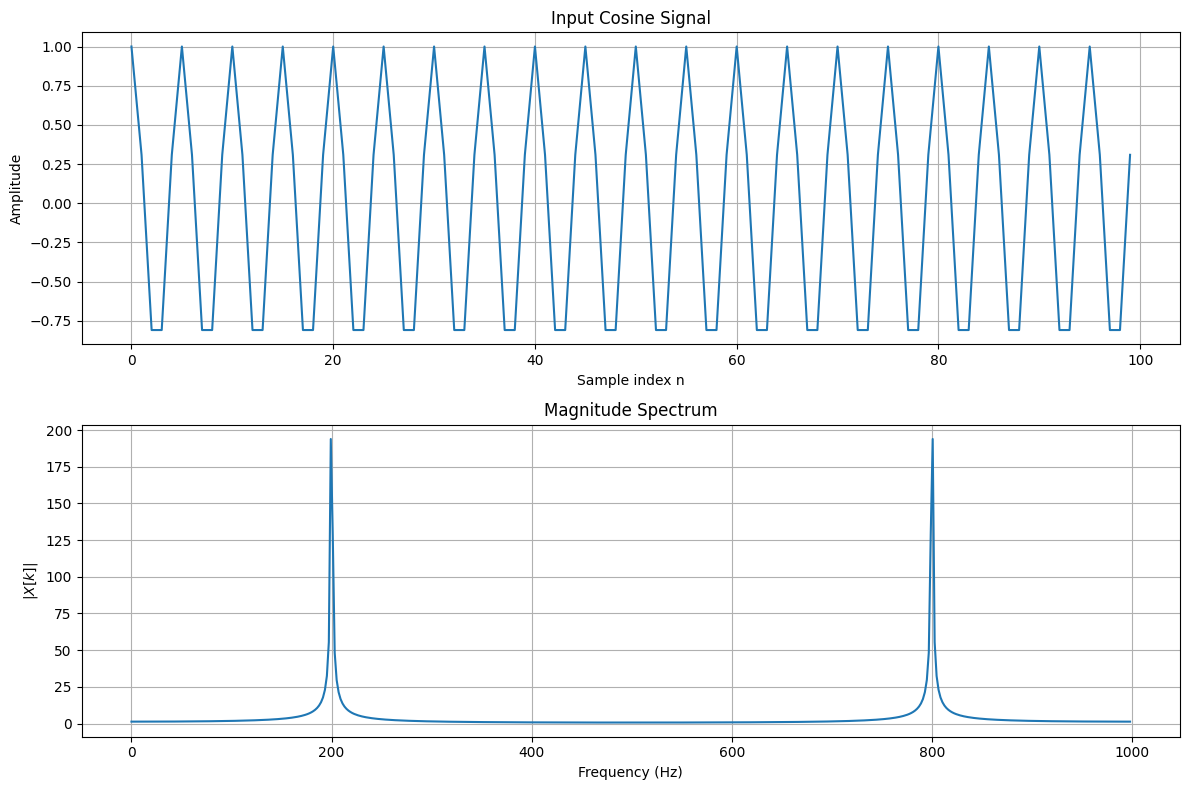

In [27]:
# Signal parameters
A = 1.0
f = 200.0
fs = 1000.0
N = 512

# Generate the cosine signal
n = np.arange(N)
x = A * np.cos(2 * np.pi * f * n / fs)

# Compute the magnitude spectrum
X_mag = gen_mag_spec(x)

# Create frequency axis in Hz
frequencies = np.arange(N) * fs / N

# Find the strongest spectral bin
peak_bin = np.argmax(X_mag)
peak_frequency = frequencies[peak_bin]

print("Peak bin:", peak_bin)
print("Peak frequency:", peak_frequency, "Hz")
print("Peak magnitude:", X_mag[peak_bin])

# Plot signal and magnitude spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot a portion of the input signal
axes[0].plot(n[:100], x[:100])
axes[0].set_title("Input Cosine Signal")
axes[0].set_xlabel("Sample index n")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

# Plot the complete magnitude spectrum
axes[1].plot(frequencies, X_mag)
axes[1].set_title("Magnitude Spectrum")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"$|X[k]|$")
axes[1].grid(True)

plt.tight_layout()
plt.show()